# Livrable 2 :

In [13]:
import tensorflow as tf
import numpy as np
import os
import sys
from tensorflow import keras

project_root = os.path.abspath(os.path.join(".."))  # One level up from current script
if project_root not in sys.path:
    sys.path.append(project_root)

from src.model_loader import ModelLoader
from src.data_loader import DataLoader
from src.utils import get_confusion_matrix, get_classification_report

print(tf.__version__)

2.19.0


## Généation du dataset de photos

In [14]:
data_loader = DataLoader()
train_ds, test_ds, val_ds = data_loader.load_unique_dataset(folder_name="/mnt/c/Users/louag/Documents/CESI/Data_science/datasets/Photo")


Photo Dataset size: 9993


## Bruitage du dataset

In [15]:
noisy_train_ds = data_loader.add_noise_to_dataset(train_ds)
noisy_val_ds = data_loader.add_noise_to_dataset(val_ds)
noisy_test_ds = data_loader.add_noise_to_dataset(test_ds)

2025-04-16 16:08:36.610956: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


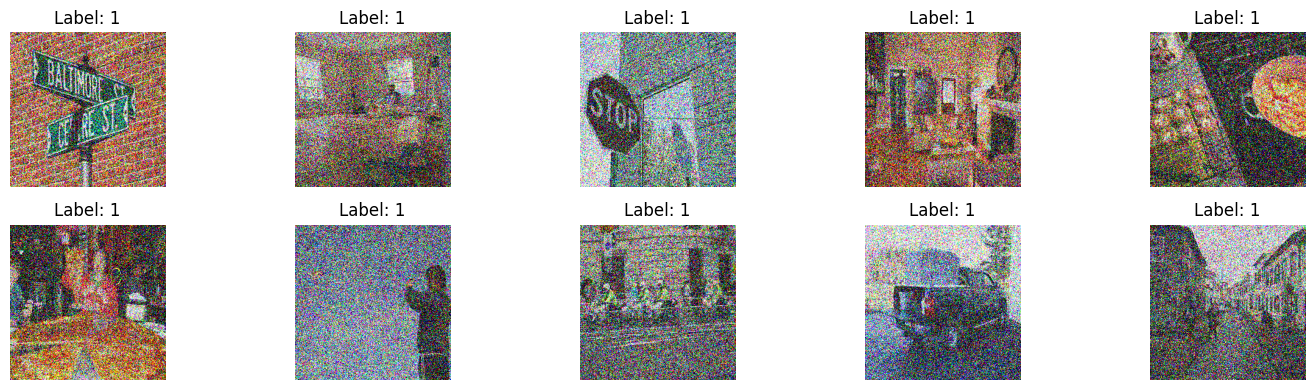

In [16]:
from src.utils import show_batch_images

show_batch_images(noisy_train_ds)

In [17]:
from keras.layers import Input, Conv2D, BatchNormalization, LeakyReLU
from keras.models import Model

encoder_inputs = Input(shape=(256, 256, 3))  # Image RGB 256x256

# --- Block 1 ---
x1 = Conv2D(32, (3, 3), strides=2, padding='same')(encoder_inputs)  # (128, 128, 32)
x1 = BatchNormalization()(x1)
x1 = LeakyReLU()(x1)

# --- Block 2 ---
x2 = Conv2D(64, (3, 3), strides=2, padding='same')(x1)  # (64, 64, 64)
x2 = BatchNormalization()(x2)
x2 = LeakyReLU()(x2)

# --- Block 3 ---
x3 = Conv2D(128, (3, 3), strides=2, padding='same')(x2)  # (32, 32, 128)
x3 = BatchNormalization()(x3)
x3 = LeakyReLU()(x3)

# --- Block 4 ---
x4 = Conv2D(256, (3, 3), strides=2, padding='same')(x3)  # (16, 16, 256)
x4 = BatchNormalization()(x4)
x4 = LeakyReLU()(x4)

# --- Block 5 ---
x5 = Conv2D(256, (3, 3), strides=2, padding='same')(x4)  # (8, 8, 256)
x5 = BatchNormalization()(x5)
x5 = LeakyReLU()(x5)

# Sorties : encoder_output + features pour skip connections
encoder = Model(inputs=encoder_inputs, outputs=[x5, x4, x3, x2, x1], name="encoder")
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 8, 8, 256)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 981,440 (3.74 MB)

 Trainable params: 979,968 (3.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [18]:
from keras.layers import Conv2DTranspose, Concatenate, Input, BatchNormalization, LeakyReLU
from keras.models import Model

# Entrées : latent + les 4 couches skip
latent_input = Input(shape=(8, 8, 256))     # Sortie finale de l'encodeur
skip4 = Input(shape=(16, 16, 256))
skip3 = Input(shape=(32, 32, 128))
skip2 = Input(shape=(64, 64, 64))
skip1 = Input(shape=(128, 128, 32))

x = latent_input

# Decode Block 1
x = Conv2DTranspose(256, (3, 3), strides=2, padding='same')(x)  # (16, 16, 256)
x = Concatenate()([x, skip4])
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Decode Block 2
x = Conv2DTranspose(128, (3, 3), strides=2, padding='same')(x)  # (32, 32, 128)
x = Concatenate()([x, skip3])
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Decode Block 3
x = Conv2DTranspose(64, (3, 3), strides=2, padding='same')(x)  # (64, 64, 64)
x = Concatenate()([x, skip2])
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Decode Block 4
x = Conv2DTranspose(32, (3, 3), strides=2, padding='same')(x)  # (128, 128, 32)
x = Concatenate()([x, skip1])
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Decode Block 5 - reconstruction finale
x = Conv2DTranspose(32, (3, 3), strides=2, padding='same')(x)  # (256, 256, 32)
decoder_output = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

# Modèle
decoder = Model(inputs=[latent_input, skip4, skip3, skip2, skip1], outputs=decoder_output, name="decoder")
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 8, 8, 256) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 16, 16,    │    590,080 │ input_layer_7[0]… │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 16, 16,    │          0 │ -                 │
│ (InputLayer)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      2,048 │ concatenate_4[0]… │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_14      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 32, 32,    │    589,952 │ leaky_re_lu_14[0… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None, 32, 32,    │          0 │ -                 │
│ (InputLayer)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ concatenate_5[0]… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_15      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_7  │ (None, 64, 64,    │    147,520 │ leaky_re_lu_15[0… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_10      │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ concatenate_6[0]… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_16      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 128, 128,  │     36,896 │ leaky_re_lu_16[0

 Total params: 1,387,619 (5.29 MB)

 Trainable params: 1,385,699 (5.29 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [19]:
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 8, 8, 256) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 16, 16,    │    590,080 │ input_layer_7[0]… │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 16, 16,    │          0 │ -                 │
│ (InputLayer)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      2,048 │ concatenate_4[0]… │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_14      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 32, 32,    │    589,952 │ leaky_re_lu_14[0… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None, 32, 32,    │          0 │ -                 │
│ (InputLayer)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ concatenate_5[0]… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_15      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_7  │ (None, 64, 64,    │    147,520 │ leaky_re_lu_15[0… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_10      │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ concatenate_6[0]… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_16      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 128, 128,  │     36,896 │ leaky_re_lu_16[0

 Total params: 1,387,619 (5.29 MB)

 Trainable params: 1,385,699 (5.29 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [20]:
def ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

In [21]:
from tensorflow.keras.models import Model

encoder_outputs = encoder(encoder_inputs)
decoded_img = decoder(encoder_outputs)

autoencoder = Model(inputs=encoder_inputs, outputs=decoded_img)

# Compilation de l'autoencodeur
autoencoder.compile(optimizer="adam", loss=ssim_loss, metrics=["mae"])

# Résumé du modèle
autoencoder.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ [(None, 8, 8,     │    981,440 │ input_layer_6[0]… │
│ (Functional)        │ 256), (None, 16,  │            │                   │
│                     │ 16, 256), (None,  │            │                   │
│                     │ 32, 32, 128),     │            │                   │
│                     │ (None, 64, 64,    │            │                   │
│                     │ 64), (None, 128,  │            │                   │
│                     │ 128, 32)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 256, 256,  │  1,387,619 │ encoder[0][0],    │
│ (Functional)        │ 3)                │            │ encoder[0][1],    │
│                     │                   │            │ encoder[0][2],    │
│                     │                   │            │ encoder[0][3],    │
│                     │                   │            │ encoder[0][4]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,369,059 (9.04 MB)

 Trainable params: 2,365,667 (9.02 MB)

 Non-trainable params: 3,392 (13.25 KB)

In [22]:
@tf.autograph.experimental.do_not_convert
def make_autoencoder_dataset(input_ds, target_ds):
    return tf.data.Dataset.zip((input_ds.map(lambda x, y: x), target_ds.map(lambda x, y: x)))

In [23]:
train_autoenc_ds = make_autoencoder_dataset(noisy_train_ds, train_ds)
val_autoenc_ds = make_autoencoder_dataset(noisy_val_ds, val_ds)

In [24]:
# Train the model
with tf.device("/gpu:0"):
    history = autoencoder.fit(train_autoenc_ds,
                    epochs=20,
                    batch_size= 32,
                    shuffle= True,
                    validation_data=val_autoenc_ds,
                    verbose=1
                   )

Epoch 1/20


2025-04-16 16:08:43.055330: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/ssim_loss/SSIM/Assert/Assert
2025-04-16 16:08:43.057058: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/ssim_loss/SSIM/Assert_1/Assert
2025-04-16 16:08:43.058084: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/ssim_loss/SSIM/Assert_2/Assert
2025-04-16 16:08:43.059027: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/ssim_loss/SSIM/Assert_3/Assert
2025-04-16 16:08:47.100125: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion', 16 bytes spill stores, 16 bytes spill loads



 46/200 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - loss: 0.7380 - mae: 0.1848

KeyboardInterrupt: 

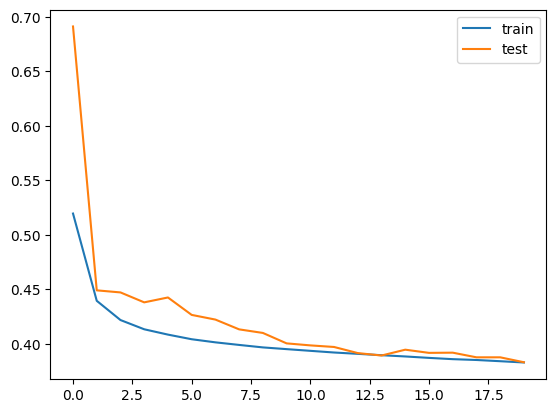

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()


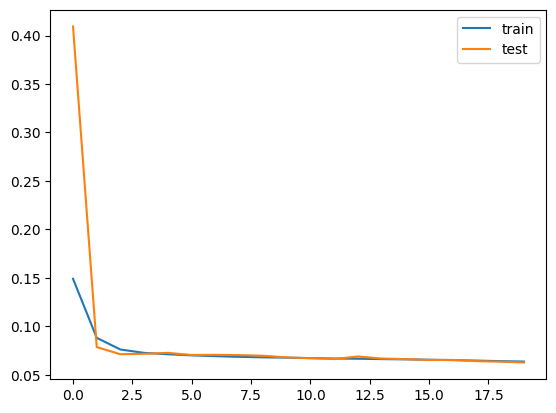

In [ ]:

plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='test')
plt.legend()

In [ ]:
def show_original_vs_decoded(noisy_dataset, clean_dataset, model, n=10):
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        raise ImportError()
    
    noisy_images, _ = next(iter(noisy_dataset))
    clean_images, _ = next(iter(clean_dataset))

    decoded_images = model.predict(noisy_images)

    plt.figure(figsize=(15, 6))
    for i in range(n):

        # Image bruitée (entrée)
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].numpy())
        plt.title("Bruitée")
        plt.axis("off")

        #  Image originale non bruitée 
        ax = plt.subplot(3, n, n + i + 1)
        plt.imshow(clean_images[i].numpy())
        plt.title("Originale")
        plt.axis("off")

        # Image reconstruite
        ax = plt.subplot(3, n, 2 * n + i + 1)
        plt.imshow(decoded_images[i])
        plt.title("Reconstruite")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


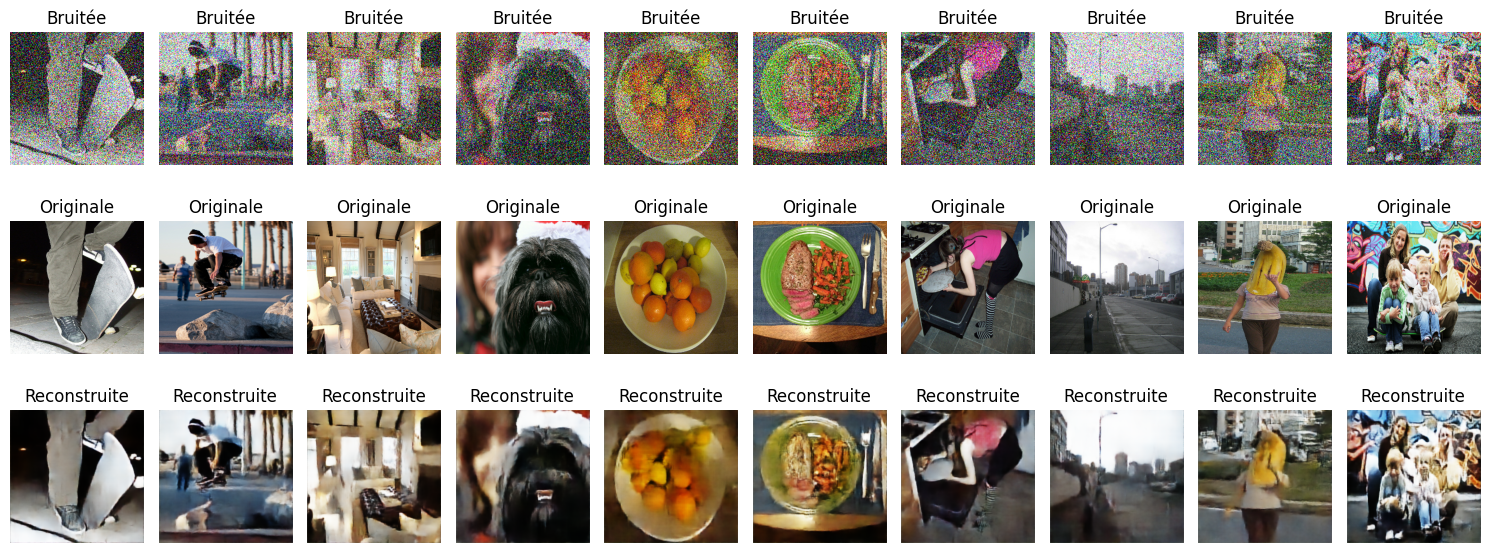

In [ ]:
show_original_vs_decoded(noisy_test_ds, test_ds, autoencoder)